In [ ]:
!pip install -U transformers

## Local Inference on GPU
Model page: https://huggingface.co/facebook/sam3

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/facebook/sam3)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

The model you are trying to use is gated. Please make sure you have access to it by visiting the model page.To run inference, either set HF_TOKEN in your environment variables/ Secrets or run the following cell to login. 🤗

In [ ]:
from huggingface_hub import login
login(new_session=False)

In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("mask-generation", model="facebook/sam3")

In [ ]:
# Load model directly
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("facebook/sam3")
model = AutoModel.from_pretrained("facebook/sam3")

In [2]:
!uv pip install inference-gpu[sam3]

Using Python 3.12.13 environment at: /usr
Resolved 214 packages in 4.68s
Prepared 102 packages in 2m 04s
Uninstalled 25 packages in 493ms
Installed 102 packages in 580ms
 + addict==2.4.0
 + aiohttp-retry==2.8.3
 + aioice==0.10.2
 + aiortc==1.14.0
 + anthropic==0.49.0
 + anyascii==0.3.3
 + apscheduler==3.11.2
 + asyncua==1.1.8
 + av==14.2.0
 + backoff==2.2.1
 + bitsandbytes==0.47.0
 + boto3==1.41.5
 + botocore==1.41.5
 - cachetools==6.2.6
 + cachetools==5.5.2
 - click==8.3.2
 + click==8.1.8
 + coloredlogs==15.0.1
 - cryptography==43.0.3
 + cryptography==46.0.7
 + dataclasses-json==0.6.7
 + decord==0.6.0
 + dnspython==2.8.0
 + docker==7.1.0
 + docopt==0.6.2
 + easyocr==1.7.2
 - fastapi==0.135.3
 + fastapi==0.115.14
 - filelock==3.25.2
 + filelock==3.17.0
 + ftfy==6.3.1
 + humanfriendly==10.0
 + hydra-core==1.3.2
 + ifaddr==0.2.0
 + inference-gpu==1.2.3
 + inference-models==0.24.4
 + iopath==0.1.10
 + isodate==0.7.2
 + jmespath==1.1.0
 + langdetect==1.0.9
 + marshmallow==3.26.2
 + mypy-ex

In [3]:
import os
os.environ["API_KEY"] = "qNXfdB49GG9sICdVeSJA"

from inference.models.sam3 import SegmentAnything3
from inference.core.entities.requests.sam3 import Sam3Prompt

# Initialize the model
# The model will automatically download weights if not present
model = SegmentAnything3(model_id="sam3/sam3_final")

# Define your image (can be a path, URL, or numpy array)
image_path = "/content/page23_img76.png"

# Define prompts
# SAM 3 supports both text and visual prompts
prompts = [
    Sam3Prompt(type="text", text="bedroom"),
    Sam3Prompt(type="text", text="toilet")
]

# Run inference
response = model.segment_image(
    image=image_path,
    prompts=prompts,
    output_prob_thresh=0.5,
    format="polygon" # or "rle", "json"
)

# Process results
for prompt_result in response.prompt_results:
    print(f"Prompt: {prompt_result.echo.text}")
    for prediction in prompt_result.predictions:
        print(f"  Confidence: {prediction.confidence}")
        print(f"  Mask: {prediction.masks}")

Prompt: bedroom
  Confidence: 0.546875
  Mask: [[[1945, 444], [1945, 451], [1945, 448], [1946, 447], [1946, 446], [1945, 445]], [[1978, 322], [1977, 323], [1975, 323], [1974, 324], [1973, 324], [1971, 326], [1970, 326], [1965, 331], [1965, 338], [1964, 339], [1964, 342], [1963, 343], [1963, 347], [1964, 348], [1964, 350], [1963, 351], [1963, 371], [1964, 372], [1964, 386], [1963, 387], [1963, 392], [1962, 393], [1962, 411], [1961, 412], [1961, 413], [1960, 414], [1960, 419], [1961, 420], [1961, 430], [1960, 431], [1960, 438], [1961, 439], [1961, 443], [1962, 444], [1962, 467], [1959, 470], [1959, 471], [1958, 472], [1956, 472], [1955, 473], [1944, 473], [1943, 474], [1942, 474], [1941, 475], [1940, 475], [1938, 477], [1938, 478], [1937, 479], [1937, 480], [1936, 481], [1936, 483], [1935, 484], [1935, 485], [1932, 488], [1931, 488], [1930, 489], [1928, 489], [1927, 490], [1920, 490], [1920, 491], [1916, 495], [1915, 495], [1914, 496], [1913, 496], [1912, 497], [1905, 497], [1904, 498], 

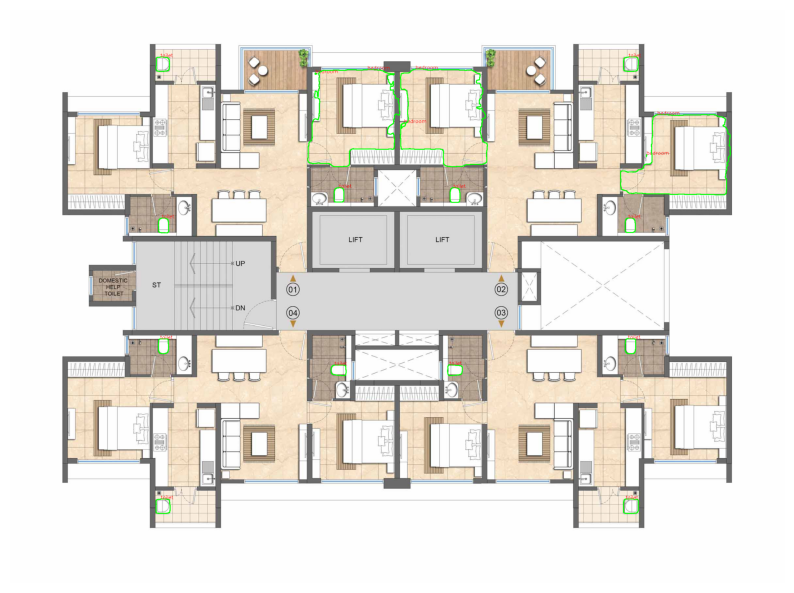

In [4]:
import cv2
import numpy as np

# Load image
image = cv2.imread("/content/page23_img76.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Loop through predictions
for prompt_result in response.prompt_results:
    label = prompt_result.echo.text

    for prediction in prompt_result.predictions:
        polygons = prediction.masks

        for poly in polygons:
            pts = np.array(poly, dtype=np.int32)

            # Draw polygon
            cv2.polylines(image, [pts], isClosed=True, color=(0, 255, 0), thickness=2)

            # Optional: fill mask
            # cv2.fillPoly(image, [pts], color=(0, 255, 0))

            # Add label (at first point)
            x, y = pts[0]
            cv2.putText(image, label, (x, y),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, (255, 0, 0), 1)

# Show image
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis("off")
plt.show()

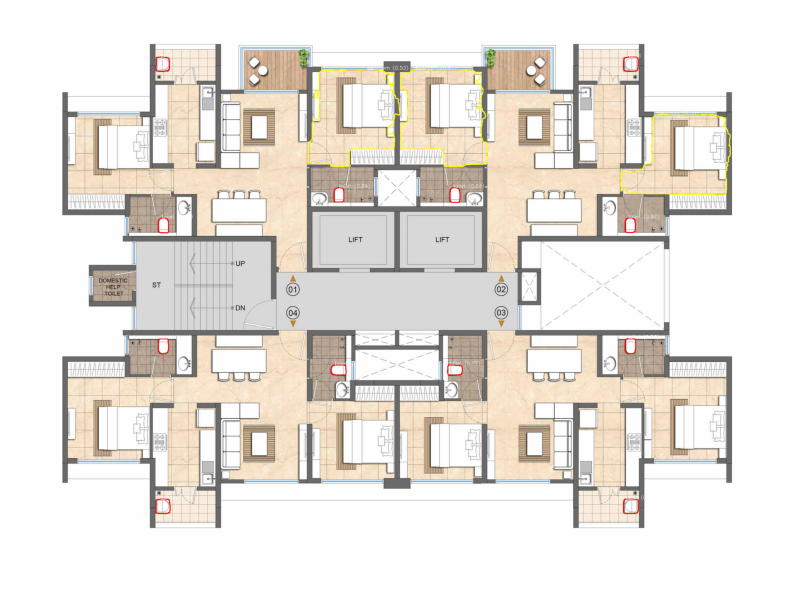

Saved annotated image: /content/sam_seg_res/annotated.png
Saved JSON: /content/sam_seg_res/results.json


In [7]:
import os
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Setup paths
# -----------------------------
image_path = "/content/page23_img76.png"
output_dir = "/content/sam_seg_res"
os.makedirs(output_dir, exist_ok=True)

# -----------------------------
# Load image
# -----------------------------
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Copy for drawing
vis_image = image_rgb.copy()

# -----------------------------
# Color map
# -----------------------------
color_map = {
    "bedroom": (255, 255, 0),
    "toilet": (255, 0, 0)
}

# -----------------------------
# Store structured output
# -----------------------------
output_data = []

# -----------------------------
# Process results
# -----------------------------
for prompt_result in response.prompt_results:
    label = prompt_result.echo.text

    for i, prediction in enumerate(prompt_result.predictions):
        confidence = float(prediction.confidence)

        # 🔥 Filter low confidence
        if confidence < 0.5:
            continue

        for j, poly in enumerate(prediction.masks):
            pts = np.array(poly, dtype=np.int32)

            # 🔥 Remove tiny noise
            if cv2.contourArea(pts) < 500:
                continue

            color = color_map.get(label, (0, 255, 255))

            # Draw polygon
            cv2.polylines(vis_image, [pts], True, color, 2)

            # Add label
            x, y = pts[0]
            cv2.putText(vis_image, f"{label} ({confidence:.2f})",
                        (x, y),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (255, 255, 255),
                        1)

            # -----------------------------
            # Save individual mask image
            # -----------------------------
            mask = np.zeros(image.shape[:2], dtype=np.uint8)
            cv2.fillPoly(mask, [pts], 255)

            mask_filename = f"{label}_{i}_{j}.png"
            cv2.imwrite(os.path.join(output_dir, mask_filename), mask)

            # -----------------------------
            # Save JSON entry
            # -----------------------------
            output_data.append({
                "label": label,
                "confidence": confidence,
                "polygon": poly,
                "mask_file": mask_filename
            })

# -----------------------------
# Save annotated image
# -----------------------------
output_image_path = os.path.join(output_dir, "annotated.png")
cv2.imwrite(output_image_path, cv2.cvtColor(vis_image, cv2.COLOR_RGB2BGR))

# -----------------------------
# Save JSON
# -----------------------------
json_path = os.path.join(output_dir, "results.json")
with open(json_path, "w") as f:
    json.dump(output_data, f, indent=4)

# -----------------------------
# Display
# -----------------------------
plt.figure(figsize=(10,10))
plt.imshow(vis_image)
plt.axis("off")
plt.show()

print(f"Saved annotated image: {output_image_path}")
print(f"Saved JSON: {json_path}")

In [8]:
!zip -r sam_seg_res.zip sam_seg_res/

  adding: sam_seg_res/ (stored 0%)
  adding: sam_seg_res/results.json (deflated 94%)
  adding: sam_seg_res/bedroom_0_1.png (deflated 81%)
  adding: sam_seg_res/toilet_6_0.png (deflated 93%)
  adding: sam_seg_res/toilet_10_0.png (deflated 94%)
  adding: sam_seg_res/toilet_4_0.png (deflated 94%)
  adding: sam_seg_res/toilet_0_0.png (deflated 95%)
  adding: sam_seg_res/toilet_5_0.png (deflated 94%)
  adding: sam_seg_res/toilet_7_0.png (deflated 94%)
  adding: sam_seg_res/bedroom_1_2.png (deflated 77%)
  adding: sam_seg_res/bedroom_2_0.png (deflated 79%)
  adding: sam_seg_res/toilet_11_0.png (deflated 94%)
  adding: sam_seg_res/toilet_9_0.png (deflated 94%)
  adding: sam_seg_res/toilet_8_0.png (deflated 95%)
  adding: sam_seg_res/toilet_1_0.png (deflated 95%)
  adding: sam_seg_res/toilet_3_0.png (deflated 95%)
  adding: sam_seg_res/toilet_2_0.png (deflated 94%)
  adding: sam_seg_res/annotated.png (deflated 15%)


In [9]:
!pip install supervision

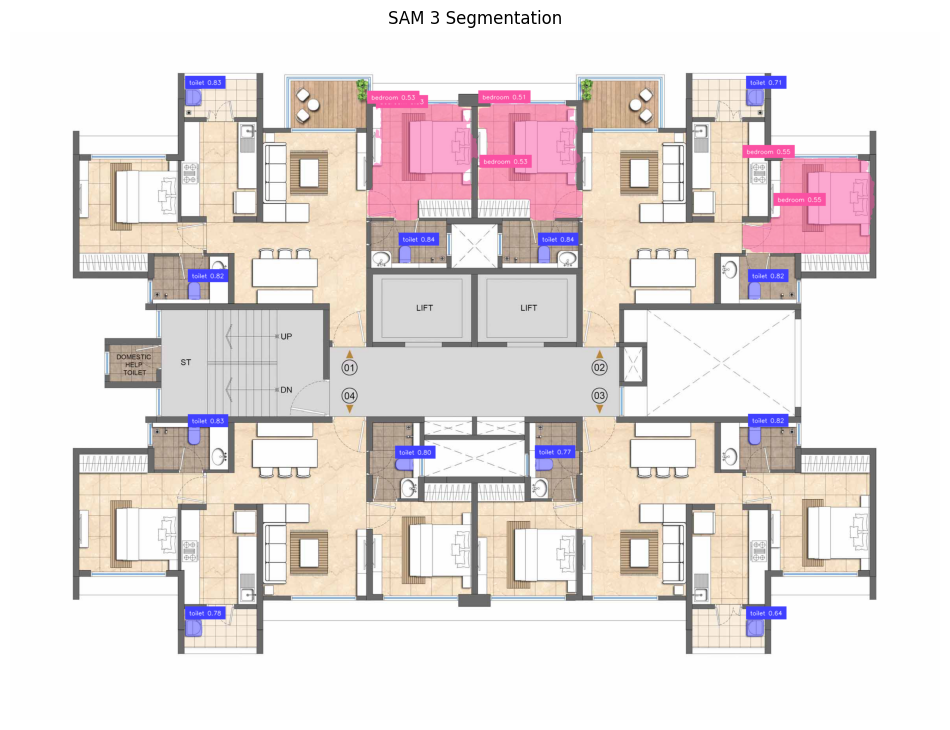

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv

# Load your original image
image_bgr = cv2.imread("/content/page23_img76.png")  # replace with your image path
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
h, w = image_rgb.shape[:2]

# Convert SAM3 polygons to Supervision detections
masks = []
xyxy = []
confidences = []
class_ids = []
labels = []

prompt_to_class = {}
next_class_id = 0

for prompt_result in response.prompt_results:
    prompt_text = prompt_result.echo.text

    if prompt_text not in prompt_to_class:
        prompt_to_class[prompt_text] = next_class_id
        next_class_id += 1

    class_id = prompt_to_class[prompt_text]

    for prediction in prompt_result.predictions:
        confidence = float(prediction.confidence)

        for polygon in prediction.masks:
            polygon = np.array(polygon, dtype=np.int32)

            # Skip bad polygons
            if polygon.ndim != 2 or polygon.shape[0] < 3:
                continue

            # Create binary mask
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillPoly(mask, [polygon], 1)

            # Compute bounding box from polygon
            x_min = polygon[:, 0].min()
            y_min = polygon[:, 1].min()
            x_max = polygon[:, 0].max()
            y_max = polygon[:, 1].max()

            masks.append(mask.astype(bool))
            xyxy.append([x_min, y_min, x_max, y_max])
            confidences.append(confidence)
            class_ids.append(class_id)
            labels.append(f"{prompt_text} {confidence:.2f}")

# Build Supervision detections
detections = sv.Detections(
    xyxy=np.array(xyxy, dtype=np.float32),
    mask=np.array(masks, dtype=bool),
    confidence=np.array(confidences, dtype=np.float32),
    class_id=np.array(class_ids, dtype=int),
    data={"labels": np.array(labels, dtype=object)}
)

# Visualize with MaskAnnotator (filled masks)
mask_annotator = sv.MaskAnnotator()
label_annotator = sv.LabelAnnotator(text_position=sv.Position.TOP_LEFT)

annotated = image_rgb.copy()
annotated = mask_annotator.annotate(scene=annotated, detections=detections)
annotated = label_annotator.annotate(scene=annotated, detections=detections, labels=labels)

plt.figure(figsize=(12, 12))
plt.imshow(annotated)
plt.axis("off")
plt.title("SAM 3 Segmentation")
plt.show()

In [11]:
polygon_annotator = sv.PolygonAnnotator(thickness=3)
annotated = polygon_annotator.annotate(scene=image_rgb.copy(), detections=detections)